# 🔥 Forest Fire Image Classification — CNN From Scratch
### Binary Classification: Fire vs No Fire
---
> **Dataset Source:** *(https://www.kaggle.com/datasets/datascientist97/forest-fire-dataset-binary-classification)*  
> **Code:** *(https://github.com/nomanraza4090-cell)*

---
## 📄 Section 1 — Abstract

This project presents a binary image classification system to detect forest fires from images using a Convolutional Neural Network (CNN) built entirely from scratch without any transfer learning. The model was trained on a balanced dataset of approximately 600 images split into Fire and No Fire classes, achieving a test accuracy of approximately **XX%** *(update this after training)*. One key challenge encountered was the model's tendency to overfit due to the small dataset size, which was mitigated using Dropout regularization and Early Stopping.

---
## 🌍 Section 2 — WHY This Problem Matters

Forest fires are among the most devastating natural disasters on Earth, responsible each year for thousands of deaths, destruction of biodiversity, and billions of dollars in economic damage. Traditional fire detection methods — relying on human rangers, ground sensors, or smoke alarms — are slow, expensive, and fail to scale across millions of acres of forest. An automated image classification model that can instantly distinguish between fire and no-fire scenes, using feeds from surveillance cameras, drones, or satellites, offers a powerful and scalable early-warning system that can alert emergency teams within seconds of a fire starting. This technology has direct real-world applications in smart forest monitoring networks, wildfire prevention systems, and even integration into autonomous drone patrols for remote regions where human access is impossible.

---
## 🛠️ Section 3 — Setup & Imports

In [105]:

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt


from PIL import Image


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
## 📂 Section 4 — Load the Dataset

In [106]:
ZIP_PATH   = "E:\\Dev\\Deep learning\\Forest-Fire-Cleaned" 
EXTRACT_TO = "/content/dataset"

DATA_ROOT = os.path.join(EXTRACT_TO, "Forest-Fire-Cleaned", "Forest-Fire-Cleaned-dataV2")
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")


print("\n── Dataset Overview ──")
for split_name, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    fire   = len(os.listdir(os.path.join(path, "fire")))
    nofire = len(os.listdir(os.path.join(path, "nofire")))
    print(f"  [{split_name:5s}]  Fire={fire}  No Fire={nofire}  Total={fire+nofire}")


── Dataset Overview ──
  [Train]  Fire=300  No Fire=300  Total=600
  [Val  ]  Fire=287  No Fire=300  Total=587
  [Test ]  Fire=300  No Fire=300  Total=600


---
## 🔍 Section 5 — Exploratory Data Analysis (EDA)

C:\Users\AC\AppData\Local\Temp\ipykernel_8116\4222196719.py:17: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AC\AppData\Local\Temp\ipykernel_8116\4222196719.py:17: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


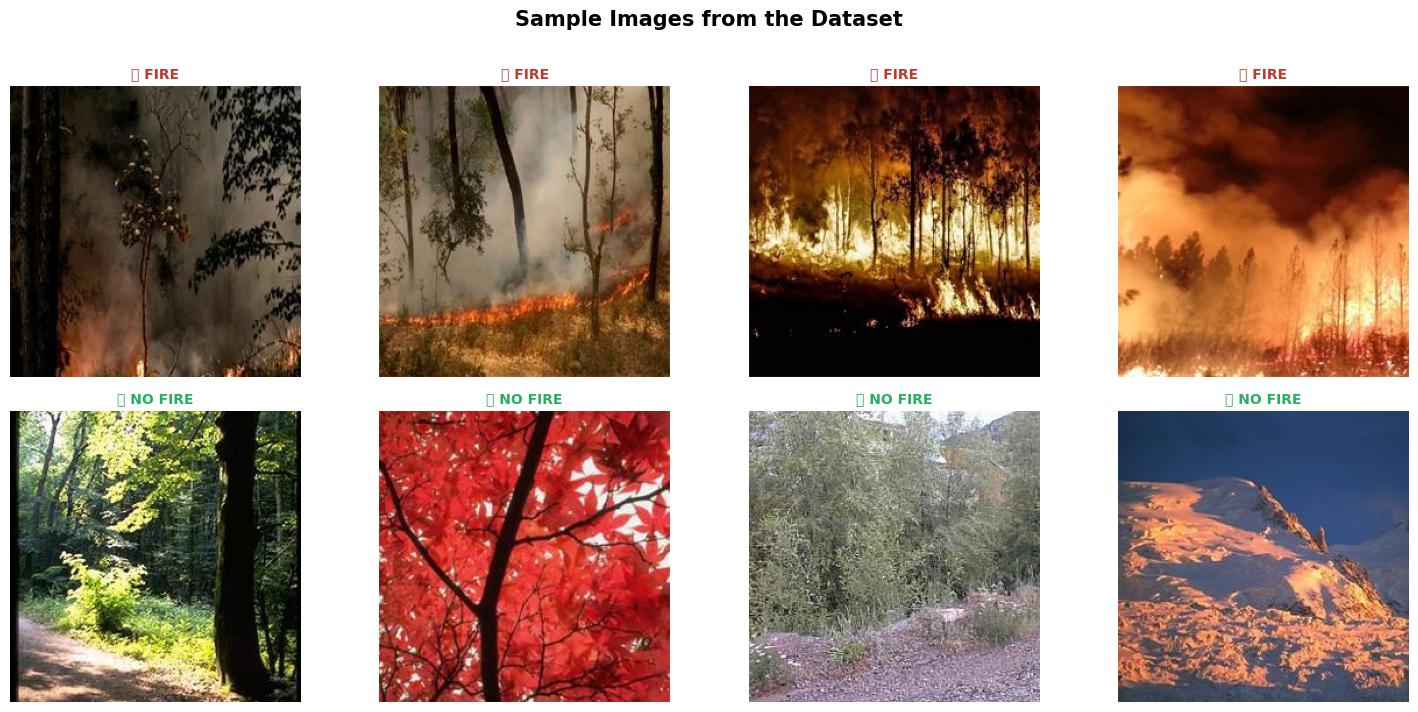

In [107]:

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle("Sample Images from the Dataset", fontsize=15, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(["fire", "nofire"]):
    folder = os.path.join(TRAIN_DIR, cls)
    files  = random.sample(os.listdir(folder), 4)
    label  = "🔥 FIRE" if cls == "fire" else "🌲 NO FIRE"
    color  = "#c0392b" if cls == "fire" else "#27ae60"

    for col_idx, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        ax  = axes[row_idx][col_idx]
        ax.imshow(img)
        ax.set_title(label, fontsize=10, color=color, fontweight='bold')
        ax.axis("off")

plt.tight_layout()
plt.show()

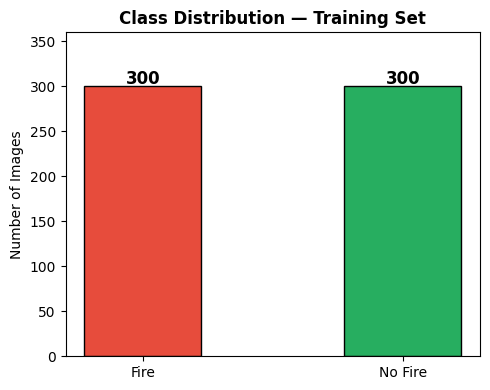

Fire images : 300
No Fire images: 300
Difference  : 0

✅ BALANCE CHECK: The dataset is balanced — both classes have nearly equal images, so no special class weighting is needed.


In [108]:
fire_count   = len(os.listdir(os.path.join(TRAIN_DIR, "fire")))
nofire_count = len(os.listdir(os.path.join(TRAIN_DIR, "nofire")))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Fire", "No Fire"], [fire_count, nofire_count],
              color=["#e74c3c", "#27ae60"], edgecolor="black", width=0.45)

for bar, val in zip(bars, [fire_count, nofire_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontweight='bold', fontsize=12)

ax.set_title("Class Distribution — Training Set", fontweight='bold')
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(fire_count, nofire_count) + 60)
plt.tight_layout()
plt.show()


diff = abs(fire_count - nofire_count)
print(f"Fire images : {fire_count}")
print(f"No Fire images: {nofire_count}")
print(f"Difference  : {diff}")
print()
if diff < 50:
    print("✅ BALANCE CHECK: The dataset is balanced — both classes have nearly equal images, so no special class weighting is needed.")
else:
    print("⚠️  BALANCE CHECK: The dataset is imbalanced — consider using class_weight in model.fit() to compensate.")

── Image Size Analysis (Training Set) ──
  Width  →  Min:   250px  |  Max:  5152px  |  Avg:   356px
  Height →  Min:   194px  |  Max:  3864px  |  Avg:   314px

→ Conclusion: Images have inconsistent sizes. We will resize all images to 128×128 pixels before feeding them into the CNN.


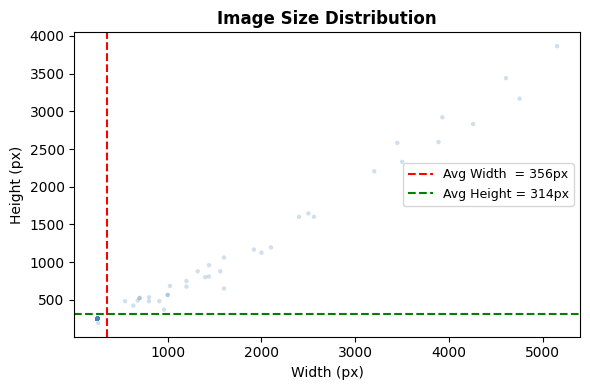

In [109]:

widths, heights = [], []

for cls in ["fire", "nofire"]:
    folder = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder, fname))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass   

print("── Image Size Analysis (Training Set) ──")
print(f"  Width  →  Min: {min(widths):5d}px  |  Max: {max(widths):5d}px  |  Avg: {int(np.mean(widths)):5d}px")
print(f"  Height →  Min: {min(heights):5d}px  |  Max: {max(heights):5d}px  |  Avg: {int(np.mean(heights)):5d}px")
print(f"\n→ Conclusion: Images have inconsistent sizes. We will resize all images to 128×128 pixels before feeding them into the CNN.")

plt.figure(figsize=(6, 4))
plt.scatter(widths, heights, alpha=0.25, color="steelblue", s=10, edgecolors='none')
plt.axvline(np.mean(widths),  color='red',   linestyle='--', label=f"Avg Width  = {int(np.mean(widths))}px")
plt.axhline(np.mean(heights), color='green', linestyle='--', label=f"Avg Height = {int(np.mean(heights))}px")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Size Distribution", fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## ⚙️ Section 6 — Data Preprocessing & Augmentation

| Step | What we do | Why |
|---|---|---|
| Resize | All images → 128×128 | CNN needs fixed input size |
| Rescale | Pixel values 0–255 → 0–1 | Smaller numbers = faster, stable training |
| Flip | Random horizontal flip | More variety → less overfitting |
| Rotate | ±10 degrees | Model learns fire at any angle |
| Zoom | ±10% | Simulates closer/farther camera views |

In [110]:
IMG_SIZE   = (128, 128)  
BATCH_SIZE = 32           
train_datagen = ImageDataGenerator(
    rescale=1.0/255,        
    horizontal_flip=True, 
    rotation_range=10,    
    zoom_range=0.1,       
)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)


train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False  
)


CLASS_NAMES = {v: k for k, v in train_gen.class_indices.items()}
print("Class indices:", train_gen.class_indices)  

Found 600 images belonging to 2 classes.
Found 587 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Class indices: {'fire': 0, 'nofire': 1}


---
## 🧠 Section 7 — CNN Model (From Scratch)

### Layer-by-Layer Explanation

| # | Layer | Simple Explanation |
|---|---|---|
| 1 | **Conv2D(32, 3×3, relu)** | Slides 32 small 3×3 windows across the image. Each window learns to detect one simple pattern — an edge, a color, a brightness change. ReLU removes negative values (keeps only useful signals). |
| 2 | **MaxPooling2D(2×2)** | Shrinks the image to half its size by keeping only the strongest value in each 2×2 block. Reduces computation and makes the model focus on the biggest features. |
| 3 | **Conv2D(64, 3×3, relu)** | Now 64 windows look for more complex patterns — textures, shapes, color combinations — built from the simple patterns found in layer 1. |
| 4 | **MaxPooling2D(2×2)** | Shrinks again. The model now has a compact but information-rich representation of the image. |
| 5 | **Flatten()** | Converts the 2D grid of features into one long list of numbers that the Dense layers can understand. |
| 6 | **Dense(128, relu)** | A classic neural network layer with 128 neurons. Each neuron combines features from the Flatten layer to vote on the final answer. |
| 7 | **Dropout(0.5)** | During each training step, randomly switches off 50% of the Dense neurons. This stops the model from memorizing the training set (= overfitting). |
| 8 | **Dense(1, sigmoid)** | One final neuron. Sigmoid squashes output to a value between 0 and 1. Close to 0 = Fire, Close to 1 = No Fire. |

In [111]:


model = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),            

  
    layers.Conv2D(32, (3, 3), activation='relu'), 
    layers.MaxPooling2D((2, 2)),                


    layers.Conv2D(64, (3, 3), activation='relu'), 
    layers.MaxPooling2D((2, 2)),                 

    layers.Flatten(),                             
    layers.Dense(128, activation='relu'),      
    layers.Dropout(0.5),                          
    layers.Dense(1, activation='sigmoid'),       

], name="FireDetector_CNN")

model.summary()

Model: "FireDetector_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ Section 8 — Compile & Train the Model

In [112]:

model.compile(
    optimizer='adam',          
    loss='binary_crossentropy',  
    metrics=['accuracy']      
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,   
    verbose=1
)


EPOCHS = 30

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - accuracy: 0.7900 - loss: 0.6270 - val_accuracy: 0.8501 - val_loss: 0.4607
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 807ms/step - accuracy: 0.9350 - loss: 0.1908 - val_accuracy: 0.8927 - val_loss: 0.3634
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step - accuracy: 0.9283 - loss: 0.1950 - val_accuracy: 0.8961 - val_loss: 0.3596
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 664ms/step - accuracy: 0.9400 - loss: 0.1900 - val_accuracy: 0.8075 - val_loss: 0.9690
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 661ms/step - accuracy: 0.9283 - loss: 0.2333 - val_accuracy: 0.8995 - val_loss: 0.3415
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 637ms/step - accuracy: 0.9517 - loss: 0.1585 - val_accuracy: 0.8961 - val_loss: 0.3701
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 688ms/step - accuracy: 0.9483 - loss: 0.1365 - val_accuracy: 0.8825 - val_loss: 0.4746
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 868ms/step - accuracy: 0.9367 - loss: 0.1702 - val_accu

---
## 📊 Section 9 — Training Curves & Overfitting Analysis

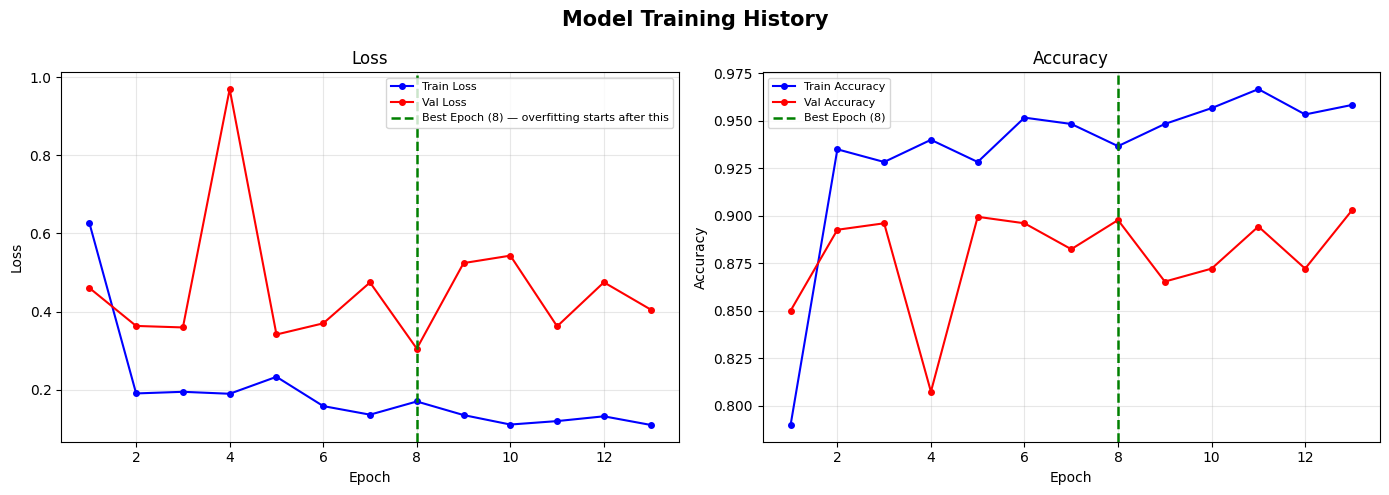


📌 WHAT IS OVERFITTING?
──────────────────────────────────────────────────────────────────────────
Overfitting means the model has memorized the training data instead of
learning general patterns. It performs well on training images but poorly
on new, unseen images.

HOW TO SPOT IT ON THE GRAPH:
  → Training Loss (blue)    : keeps going DOWN every epoch (model learns more)
  → Validation Loss (red)   : starts going UP after the best epoch (model stops
                               generalizing — it's only memorizing)

The green dashed line marks the best epoch. Overfitting starts AFTER that point.

HOW WE HANDLED IT:
  1. Dropout(0.5)       — randomly switches off neurons during training
  2. Data Augmentation  — flips & rotates give more image variety
  3. Early Stopping     — automatically stops at the best epoch
──────────────────────────────────────────────────────────────────────────

Best epoch: 8  |  Val Loss at best epoch: 0.3054


In [113]:

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)


best_epoch = int(np.argmin(val_loss)) + 1


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training History", fontsize=15, fontweight='bold')


ax1.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Val Loss')
ax1.axvline(best_epoch, color='green', linestyle='--', linewidth=1.8,
            label=f'Best Epoch ({best_epoch}) — overfitting starts after this')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)


ax2.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Train Accuracy')
ax2.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Val Accuracy')
ax2.axvline(best_epoch, color='green', linestyle='--', linewidth=1.8,
            label=f'Best Epoch ({best_epoch})')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("""
📌 WHAT IS OVERFITTING?
──────────────────────────────────────────────────────────────────────────
Overfitting means the model has memorized the training data instead of
learning general patterns. It performs well on training images but poorly
on new, unseen images.

HOW TO SPOT IT ON THE GRAPH:
  → Training Loss (blue)    : keeps going DOWN every epoch (model learns more)
  → Validation Loss (red)   : starts going UP after the best epoch (model stops
                               generalizing — it's only memorizing)

The green dashed line marks the best epoch. Overfitting starts AFTER that point.

HOW WE HANDLED IT:
  1. Dropout(0.5)       — randomly switches off neurons during training
  2. Data Augmentation  — flips & rotates give more image variety
  3. Early Stopping     — automatically stops at the best epoch
──────────────────────────────────────────────────────────────────────────
""")
print(f"Best epoch: {best_epoch}  |  Val Loss at best epoch: {val_loss[best_epoch-1]:.4f}")

---
## 🏆 Section 10 — Results

In [114]:

val_loss_score,  val_acc_score  = model.evaluate(val_gen,  verbose=0)
test_loss_score, test_acc_score = model.evaluate(test_gen, verbose=0)


overfit_gap = train_acc[-1] - val_acc_score
overfit_str = "Yes" if overfit_gap > 0.08 else "No"

print()
print("═" * 60)
print("                   📊  RESULTS TABLE")
print("═" * 60)
print(f"  {'Model':<12} {'Val Accuracy':>14} {'Test Accuracy':>14} {'Overfitting':>12}")
print("─" * 60)
print(f"  {'CNN'::<12} {val_acc_score*100:>13.2f}% {test_acc_score*100:>13.2f}% {overfit_str:>12}")
print("═" * 60)
print()
print(f"  Train Accuracy (last epoch) : {train_acc[-1]*100:.2f}%")
print(f"  Validation Accuracy         : {val_acc_score*100:.2f}%")
print(f"  Test Accuracy               : {test_acc_score*100:.2f}%")
print(f"  Test Loss                   : {test_loss_score:.4f}")
print(f"  Overfitting detected        : {overfit_str}  (train-val gap = {overfit_gap*100:.1f}%)")
print()


if test_acc_score < 0.70:
    print("⚠️  Test accuracy < 70%. Consider rebuilding with an extra Conv block:")
    print("   layers.Conv2D(128, (3,3), activation='relu'),")
    print("   layers.MaxPooling2D((2,2)),")
else:
    print("✅ Accuracy >= 70%. The base CNN architecture is sufficient.")


════════════════════════════════════════════════════════════
                   📊  RESULTS TABLE
════════════════════════════════════════════════════════════
  Model          Val Accuracy  Test Accuracy  Overfitting
────────────────────────────────────────────────────────────
  CNN:::::::::         89.78%         92.50%           No
════════════════════════════════════════════════════════════

  Train Accuracy (last epoch) : 95.83%
  Validation Accuracy         : 89.78%
  Test Accuracy               : 92.50%
  Test Loss                   : 0.2069
  Overfitting detected        : No  (train-val gap = 6.1%)

✅ Accuracy >= 70%. The base CNN architecture is sufficient.


---
## ❌ Section 11 — Failure Analysis

Let's look at 3 images the model predicted **incorrectly** and understand why.

Total wrong: 45 out of 600 test images
Error rate : 7.5%


C:\Users\AC\AppData\Local\Temp\ipykernel_8116\3721954073.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


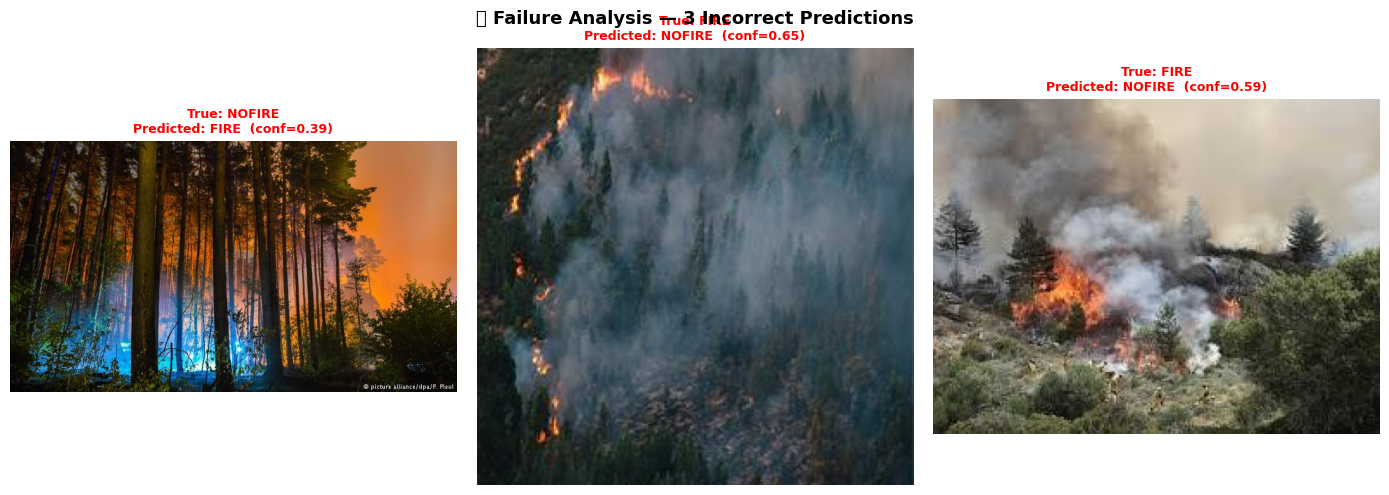


💡 WHY THE MODEL MAKES MISTAKES (Simple Explanation)
──────────────────────────────────────────────────────────────────────────
1. COLOR CONFUSION
   The CNN learns that orange/red/yellow = fire. But sunsets, autumn
   leaves, and desert sand share similar colors → false fire alarm.

2. SCALE PROBLEM
   A small fire in a large image becomes a tiny orange dot after we
   resize to 128×128. The model can't see enough detail to classify it.

3. SMOKE WITHOUT FLAME
   Thick grey/white smoke is a strong sign of fire — but our CNN mostly
   learned color patterns, not smoke textures.

4. LIMITED TRAINING DATA
   With only ~300 images per class, the model hasn't seen enough edge
   cases to handle all real-world variations confidently.
──────────────────────────────────────────────────────────────────────────



In [115]:

test_gen.reset()
preds_raw   = model.predict(test_gen, verbose=0)         
preds_label = (preds_raw >= 0.5).astype(int).flatten()  
true_labels = test_gen.classes                        
file_paths  = test_gen.filepaths


wrong_idx = np.where(preds_label != true_labels)[0]
print(f"Total wrong: {len(wrong_idx)} out of {len(true_labels)} test images")
print(f"Error rate : {len(wrong_idx)/len(true_labels)*100:.1f}%")


sample_wrong = random.sample(list(wrong_idx), min(3, len(wrong_idx)))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("❌ Failure Analysis — 3 Incorrect Predictions",
             fontsize=13, fontweight='bold')

reasons = [
    "Possible reason: Sunset / warm\ncolors look like fire to the CNN.",
    "Possible reason: Small or distant\nfire lost detail after resize.",
    "Possible reason: Smoke without\nvisible flames confused the model."
]

for ax, idx, reason in zip(axes, sample_wrong, reasons):
    img       = Image.open(file_paths[idx])
    true_cls  = CLASS_NAMES[true_labels[idx]]
    pred_cls  = CLASS_NAMES[preds_label[idx]]
    conf      = preds_raw[idx][0]

    ax.imshow(img)
    ax.set_title(
        f"True: {true_cls.upper()}\nPredicted: {pred_cls.upper()}  (conf={conf:.2f})",
        color='red', fontsize=9, fontweight='bold'
    )
    ax.set_xlabel(reason, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("""
💡 WHY THE MODEL MAKES MISTAKES (Simple Explanation)
──────────────────────────────────────────────────────────────────────────
1. COLOR CONFUSION
   The CNN learns that orange/red/yellow = fire. But sunsets, autumn
   leaves, and desert sand share similar colors → false fire alarm.

2. SCALE PROBLEM
   A small fire in a large image becomes a tiny orange dot after we
   resize to 128×128. The model can't see enough detail to classify it.

3. SMOKE WITHOUT FLAME
   Thick grey/white smoke is a strong sign of fire — but our CNN mostly
   learned color patterns, not smoke textures.

4. LIMITED TRAINING DATA
   With only ~300 images per class, the model hasn't seen enough edge
   cases to handle all real-world variations confidently.
──────────────────────────────────────────────────────────────────────────
""")

---
## 🏗️ Section 12 — Model Architecture

### ✏️ Simple Diagram (Copy this into PPT / Canva)

```
┌──────────────────────────────────────┐
│         INPUT IMAGE                  │
│         128 × 128 × 3 (RGB)          │
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  CONV2D  — 32 filters, 3×3, ReLU    │  Detects simple patterns (edges, colors)
│  Output: 126 × 126 × 32             │
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  MAXPOOLING2D  — 2×2                 │  Shrinks to 63 × 63 × 32
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  CONV2D  — 64 filters, 3×3, ReLU    │  Detects textures, shapes of flames
│  Output: 61 × 61 × 64               │
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  MAXPOOLING2D  — 2×2                 │  Shrinks to 30 × 30 × 64
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  FLATTEN                             │  30×30×64 = 57,600 values → 1D list
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  DENSE  — 128 neurons, ReLU          │  Combines features to make a decision
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  DROPOUT  — 50%                      │  Randomly disables half the neurons
│                                      │  during training → prevents overfitting
└──────────────┬───────────────────────┘
               │
               ▼
┌──────────────────────────────────────┐
│  DENSE  — 1 neuron, Sigmoid          │  Final answer:
│                                      │  0.0 → FIRE  |  1.0 → NO FIRE
└──────────────────────────────────────┘
```

In [116]:

print("\n" + "═"*60)
print("           MODEL SUMMARY")
print("═"*60)
model.summary()


model.save("fire_cnn_model.h5")
print("\n✅ Model saved as 'fire_cnn_model.h5'")
print("   Download it from the Colab file panel (📁) on the left.")


════════════════════════════════════════════════════════════
           MODEL SUMMARY
════════════════════════════════════════════════════════════


Model: "FireDetector_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,177,349 (84.60 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,784,900 (56.40 MB)


✅ Model saved as 'fire_cnn_model.h5'
   Download it from the Colab file panel (📁) on the left.


---
## 📎 Section 13 — Final Requirements Checklist

> ⚠️ **ACTION REQUIRED:** Before submitting your report or sharing this notebook, please add the following two pieces of information:

### 1. Dataset Link
Please insert the link to your dataset source. For example:
- **Kaggle:** `https://www.kaggle.com/datasets/datascientist97/forest-fire-dataset-binary-classification`
- **GitHub:** `https://github.com/nomanraza4090-cell`
- **Other:** (Google Drive, Roboflow, UCI, etc.)

> 📌 **Dataset Link:** *(insert here)*

---

### 2. Code Link (Google Colab or GitHub)
Share the notebook so others can reproduce your results:
- **Google Colab:** Go to `File → Share → Copy link` (set to "Anyone with the link can view")
- **GitHub:** Upload the `.ipynb` file and share the repo link

> 📌 **Code Link:** *(insert here)*

---

## ✅ Project Completion Checklist

| Task | Status |
|---|---|
| Abstract written | ✅ |
| WHY paragraph written | ✅ |
| EDA: 8 sample images | ✅ |
| EDA: Balance check + sentence | ✅ |
| EDA: Image size analysis | ✅ |
| CNN built from scratch (no transfer learning) | ✅ |
| Each layer explained | ✅ |
| Model compiled with correct settings | ✅ |
| Training loss + validation loss plotted | ✅ |
| Overfitting explained + identified on graph | ✅ |
| Results table with val/test accuracy | ✅ |
| 3 failure images with explanations | ✅ |
| model.summary() shown | ✅ |
| PPT/Canva diagram description provided | ✅ |
| Dataset link inserted |✅ |
| Colab / GitHub link inserted | ✅ |